<center><h1 style="color:teal;"><strong>Handling Missing values</strong></h1></center>

<h3><strong>What is missing Values?</strong></h3>

Missing values (often presented as NaN,null,none) occur when no data value is stored for a variable in observation.

<h3><strong>Why does missing data occur?</strong></h3>

- Data entry error: Human oversight during manual input.
- Equipment Malfunction: Sensors failling or losing connectivity
- Non-Response: In surveys, people might feel uncomfortable answering questions, Income , health, or weight etc.
- Data Integration Issues: Merging two databases where one lacks a column present in the other

<h3><strong>Impact on ML Models</strong></h3>

Most scikit learn algorithms can not handle missing values and will throw an error.

<strong>Ignoring the problem leads to:</strong>

- Bias: If the data is missing for specific reason, deleting it changes the TRUTH of your dataset.
- Loss of Power: Reduced sample size leads to less reliable models.

<h3><strong>Types of Missing Data</strong></h3>

1. MCAR(Missing Completely at Random): There probability of being missing is the same for all observations. there is no relationship between the missing data and any other values.
2. MAR(Missing at Random): The missingness is related to observed data. but not the missing values themselves.
3. MNAR(Missing Not at Random): The missingness depends on the unobserved value itself. This is hardest to handle.

<h3><strong>Ways to handle Missing values</strong></h3>

1. Remove Them (Rows,columns)
2. Impute

<h2><strong>Imputation</strong></h2>

1. Univariate(Numerical Data, Categorical Data)
2. Multivariate(KNN Imputation,Iterative Imputation)

<center><h3 style="color:Green;"><strong>Remove Them</strong></h3></center>

<h3><strong >Removing the rows</strong>

Row deletion, Known as <strong>listwise deletion</strong>, means that if a single "cell" in a row is NaN, the entire record is going to removed from dataset.

<strong>When it is GOOD to use</strong>

- Low Percentage: if < 5% of you data is missing.
- MCAR: The missingness has no hidden pattern.
- Large Datasets: If you have millions of rows, losing 100 won't hurt your model's performance.

<strong>When it is NOT recommended</strong>

- Small datasets: If only 100 rows, every singel row is precious.
- Bias risk: If only "High income" individuals refused to answer the survey, dropping thos rows , removes you "High income" represntation entirely.

In [1]:
import pandas as pd
import numpy as np


data = {
    "Name":["A","B","C","D","E","F"],
    "Age":[25,np.nan,30,35,np.nan,40],
    "Score":[85,90,np.nan,88,92,95],
    "Attendance":[100,90,80,np.nan,90,85]
}

df = pd.DataFrame(data)

In [2]:
df

,Name,Age,Score,Attendance
0,A,25.0,85.0,100.0
1,B,NaN,90.0,90.0
2,C,30.0,NaN,80.0
3,D,35.0,88.0,NaN
4,E,NaN,92.0,90.0
5,F,40.0,95.0,85.0


In [2]:
df_dropped = df.dropna()
print(df_dropped)

  Name   Age  Score  Attendance
0    A  25.0   85.0       100.0
5    F  40.0   95.0        85.0


In [3]:
df_subset = df.dropna(subset=['Age','Score'])
print(df_subset)

  Name   Age  Score  Attendance
0    A  25.0   85.0       100.0
3    D  35.0   88.0         NaN
5    F  40.0   95.0        85.0


In [4]:
df_thresh = df.dropna(thresh=4)#if you are having atleast n(threshold) non-NaN values
print(df_thresh)

  Name   Age  Score  Attendance
0    A  25.0   85.0       100.0
5    F  40.0   95.0        85.0


<h3><strong>Removing the columns</strong></h3>

Columns deletion involves removing an entire variable from the dataset:

Imapact: You are reducing you feature space(Dimensionality).

<strong>When it is GOOD to use</strong>

- High missingness: If column is missing >50% of its values. 
- Irrelvance: If the feature is not crucial for the prediction.


<strong>When It is not Recommended</strong>

- Domain Importance: If it crucial for rest of the features.

In [5]:
df["Notes"] = [np.nan,"Good",np.nan,np.nan,np.nan,"Average"]

In [14]:
df

,Name,Age,Score,Attendance,Notes
0,A,25.0,85.0,100.0,NaN
1,B,NaN,90.0,90.0,Good
2,C,30.0,NaN,80.0,NaN
3,D,35.0,88.0,NaN,NaN
4,E,NaN,92.0,90.0,NaN
5,F,40.0,95.0,85.0,Average


In [6]:
missing_pct = df.isnull().sum() / len(df) *100

In [ ]:
limit = 50
cols_to_drop = missing_pct[missing_pct>50].index
df_reduced = df.drop(columns=cols_to_drop)

In [21]:
df_reduced

,Name,Age,Score,Attendance
0,A,25.0,85.0,100.0
1,B,NaN,90.0,90.0
2,C,30.0,NaN,80.0
3,D,35.0,88.0,NaN
4,E,NaN,92.0,90.0
5,F,40.0,95.0,85.0


In [18]:
df.isnull()

,Name,Age,Score,Attendance,Notes
0,False,False,False,False,True
1,False,True,False,False,False
2,False,False,True,False,True
3,False,False,False,True,True
4,False,True,False,False,True
5,False,False,False,False,False


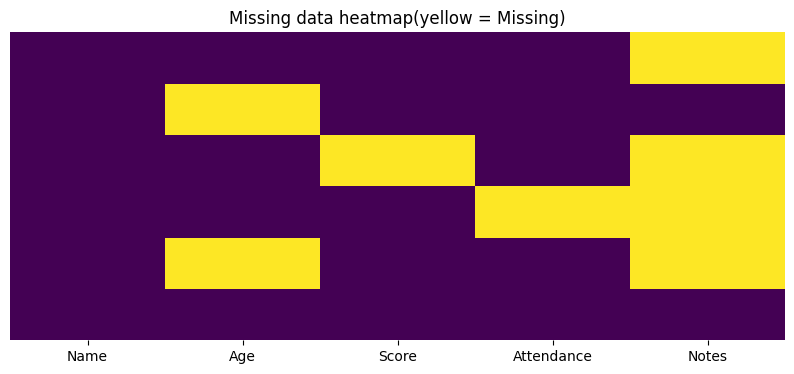

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title("Missing data heatmap(yellow = Missing)")
plt.show()

In [9]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
df_real = pd.DataFrame(data.data,columns=data.feature_names)

In [11]:
df_real.iloc[0:500,0] = np.nan
df_real["Garbage_Feature"] = np.nan

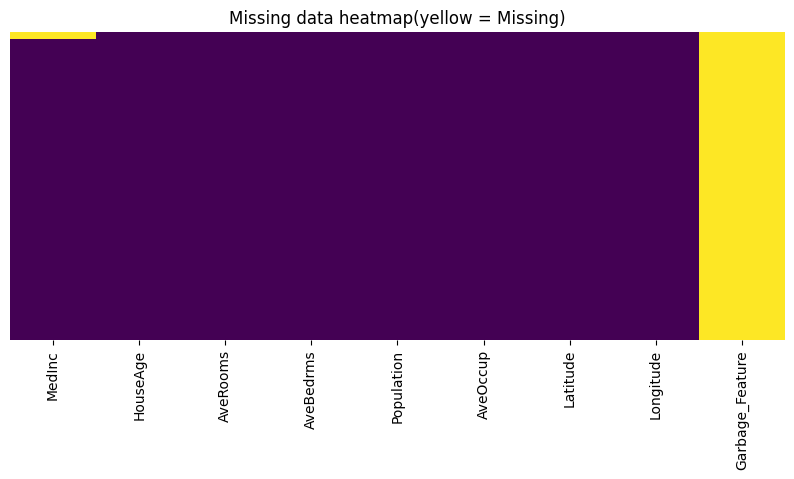

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.heatmap(df_real.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title("Missing data heatmap(yellow = Missing)")
plt.show()

In [13]:
df_real.tail(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Garbage_Feature
20620,4.5625,40.0,4.125000,0.854167,151.0,3.145833,39.05,-121.48,NaN
20621,2.3661,37.0,7.923567,1.573248,484.0,3.082803,39.01,-121.47,NaN
20622,2.4167,20.0,4.808917,0.936306,457.0,2.910828,39.00,-121.44,NaN
20623,2.8235,32.0,5.101322,1.074890,598.0,2.634361,39.03,-121.37,NaN
20624,3.0739,16.0,5.835052,1.030928,731.0,2.512027,39.04,-121.41,NaN
20625,4.1250,37.0,7.285714,1.214286,29.0,2.071429,39.12,-121.52,NaN
20626,2.1667,36.0,6.573099,1.076023,504.0,2.947368,39.18,-121.43,NaN
20627,3.0000,5.0,6.067797,1.101695,169.0,2.864407,39.13,-121.32,NaN
20628,2.5952,19.0,5.238462,1.079487,1018.0,2.610256,39.10,-121.48,NaN
20629,2.0943,28.0,5.519802,1.020902,6912.0,3.801980,39.12,-121.39,NaN


In [14]:
df_cleaned = df_real.dropna(axis=1,how='all')

In [16]:
df_cleand2 = df_cleaned.dropna(subset=["MedInc"])

In [17]:
df_cleand2

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
500,1.5817,52.0,5.438017,1.173554,875.0,2.410468,37.85,-122.27
501,2.2841,52.0,4.350649,1.077922,152.0,1.974026,37.85,-122.27
502,1.3785,47.0,4.310345,0.962382,843.0,2.642633,37.85,-122.27
503,2.9018,52.0,4.621212,1.098485,281.0,2.128788,37.85,-122.28
504,1.7300,44.0,5.024510,0.970588,506.0,2.480392,37.85,-122.28
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


<h3><strong>Univariate</strong></h3>

Univariate Imputation is a method where we fill missing values in specific column based solely on the statistics of that column(eg. mean, median, mode), We do not look at other variables in the dataset to make our guess.

1. Numerical Feature

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
data = {
    "Age":np.random.normal(30,10,1000).tolist(),
    "Salary":np.random.exponential(50000,1000).tolist()
}

In [21]:
df = pd.DataFrame(data)

In [22]:
df.head()

,Age,Salary
0,34.967142,9165.056757
1,28.617357,5522.440864
2,36.476885,50589.205735
3,45.230299,61289.746976
4,27.658466,1604.787337


In [23]:
for col in df.columns:
    df.loc[df.sample(frac=0.1).index,col] = np.nan

In [25]:
df.isnull().sum()

Age       100
Salary    100
dtype: int64

In [26]:
df.describe()

,Age,Salary
count,900.000000,900.000000
mean,30.165083,49277.386695
std,9.749172,48973.176270
min,-2.412673,161.172668
25%,23.491180,14178.116953
50%,30.077384,35751.649619
75%,36.479439,66688.895839
max,68.527315,372086.145485


a. Mean Imputation

In [30]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [27]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy='mean')
df["Age_mean"] = mean_imputer.fit_transform(df[['Age']])

In [29]:
df.isnull().sum()

Age         100
Salary      100
Age_mean      0
dtype: int64

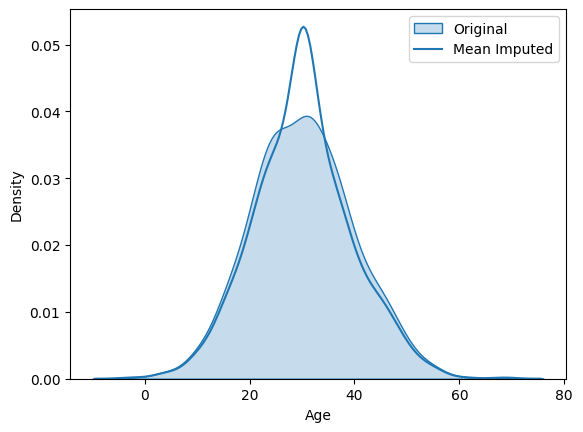

In [31]:
sns.kdeplot(df["Age"],label="Original",fill=True)
sns.kdeplot(df["Age_mean"],label="Mean Imputed")
plt.legend()
plt.show()

b. Median Imputation

In [32]:
median_imputer = SimpleImputer(strategy='median')
df['Salary_Median'] = median_imputer.fit_transform(df[['Salary']])

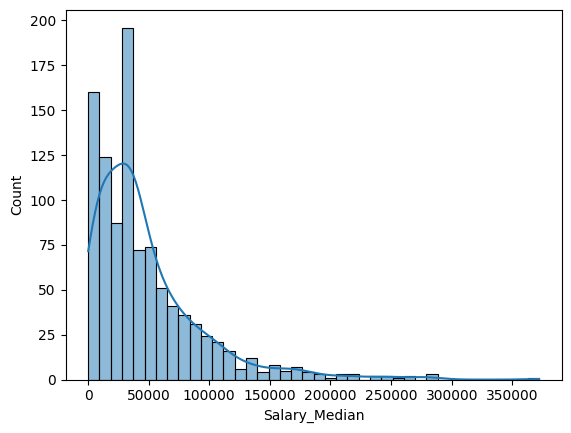

In [33]:
sns.histplot(df['Salary_Median'],kde=True)
plt.show()

c. Random Value Imputation

In [ ]:
def random_value_imputation(series):
    data = series.copy()
    random_samples = data.dropna().sample(data.isnull().sum(),random_state=42)
    random_samples.index = data[data.isnull()].index
    data.loc[data.isnull()] = random_samples
    return data

In [35]:
df["Age_random"] = random_value_imputation(df["Age"])

In [36]:
df

,Age,Salary,Age_mean,Salary_Median,Age_random
0,34.967142,9165.056757,34.967142,9165.056757,34.967142
1,NaN,5522.440864,30.165083,5522.440864,45.646437
2,36.476885,50589.205735,36.476885,50589.205735,36.476885
3,45.230299,61289.746976,45.230299,61289.746976,45.230299
4,27.658466,1604.787337,27.658466,1604.787337,27.658466
...,...,...,...,...,...
995,NaN,16472.671396,30.165083,16472.671396,19.189367
996,47.976865,11596.134927,47.976865,11596.134927,47.976865
997,36.408429,36342.709466,36.408429,36342.709466,36.408429
998,24.288210,NaN,24.288210,35751.649619,24.288210


d. End of Distribution Imputation

In [37]:
extreme_val = df['Age'].mean() + 3 * df['Age'].std()

In [38]:
extreme_val

np.float64(59.412597985626135)

In [39]:
df['Age_EndDist'] = df['Age'].fillna(extreme_val)

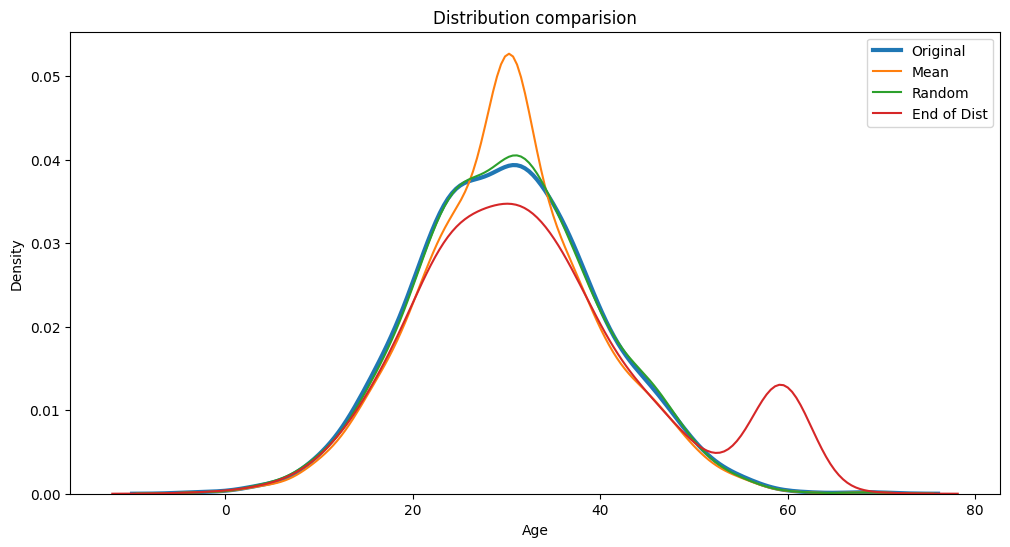

In [41]:
plt.figure(figsize=(12,6))
sns.kdeplot(df['Age'],label='Original',lw=3)
sns.kdeplot(df['Age_mean'],label="Mean")
sns.kdeplot(df['Age_random'],label='Random')
sns.kdeplot(df['Age_EndDist'],label='End of Dist')
plt.title("Distribution comparision")
plt.legend()
plt.show()

2. Categorical Feature

In [42]:
data ={
    'City':["Delhi","Pune","Pune","Mumbai",np.nan,"Pune","Delhi",np.nan,"Mumbai","Pune"],
    "Membership":["gold","silver",np.nan,'sliver',"gold","sliver",np.nan,np.nan,"silver","silver"]
}

In [47]:
df = pd.DataFrame(data)

In [48]:
df['City'].value_counts()

City
Pune      4
Delhi     2
Mumbai    2
Name: count, dtype: int64

In [50]:
df.shape

(10, 2)

In [45]:
df.isnull().sum()

City          2
Membership    3
dtype: int64

a. Mode Imputation

In [52]:
from sklearn.impute import SimpleImputer

imputer_mode = SimpleImputer(strategy='most_frequent')
df['city_mode'] = imputer_mode.fit_transform(df[['City']]).ravel()

In [53]:
df

,City,Membership,city_mode
0,Delhi,gold,Delhi
1,Pune,silver,Pune
2,Pune,NaN,Pune
3,Mumbai,sliver,Mumbai
4,NaN,gold,Pune
5,Pune,sliver,Pune
6,Delhi,NaN,Delhi
7,NaN,NaN,Pune
8,Mumbai,silver,Mumbai
9,Pune,silver,Pune


b. Constant Value Imputation

In [54]:
df['Membership_Fixed'] = df['Membership'].fillna("Missing")

In [55]:
df

,City,Membership,city_mode,Membership_Fixed
0,Delhi,gold,Delhi,gold
1,Pune,silver,Pune,silver
2,Pune,NaN,Pune,Missing
3,Mumbai,sliver,Mumbai,sliver
4,NaN,gold,Pune,gold
5,Pune,sliver,Pune,sliver
6,Delhi,NaN,Delhi,Missing
7,NaN,NaN,Pune,Missing
8,Mumbai,silver,Mumbai,silver
9,Pune,silver,Pune,silver
